<a href="https://colab.research.google.com/github/sofol-bit/LinSofoNEUR265/blob/main/homework/coding_homework_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Lindsey Sofo
*Introduction to Neural Data Analysis*

**April 7th, 2026**

In [1]:
# 2 import modules

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [2]:
#3 import data as numpy arrays

fear_traces = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/fear_conditioning_traces_hw8.csv', delimiter = ',')
extinction_predictors = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/extinction_predictors_hw8.csv')
shock_index = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/shock_index.csv', delimiter = ',').astype(int)
tone_index = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/tone_index.csv', delimiter = ',').astype(int)

In [3]:
# check size of fear traces for ref

print(fear_traces.shape)

(24668, 63)


In [4]:
# 5 split fear traces into conditioning/extinction

conditioning_traces = fear_traces[:10458, :]
extinction_traces = fear_traces[10458:, ]

In [5]:
# 6 print size of new variables/split fear traces

print(conditioning_traces.shape)
print(extinction_traces.shape)

(10458, 63)
(14210, 63)


In [6]:
# 7 make time varibles
time_conditioning = np.linspace(0, 10458/15, 10458)
print(10458/15)
print((10458/15)/60)

time_extinction = np.linspace(0, 14210/15, 14210)
print(14210/15)
print((14210/15)/60)

697.2
11.620000000000001
947.3333333333334
15.78888888888889


ROI: 63
conditioning: 697.2 sec, 11.62min
extinction: 947.33 sec, 15.79 min

(0.0, 700.0)

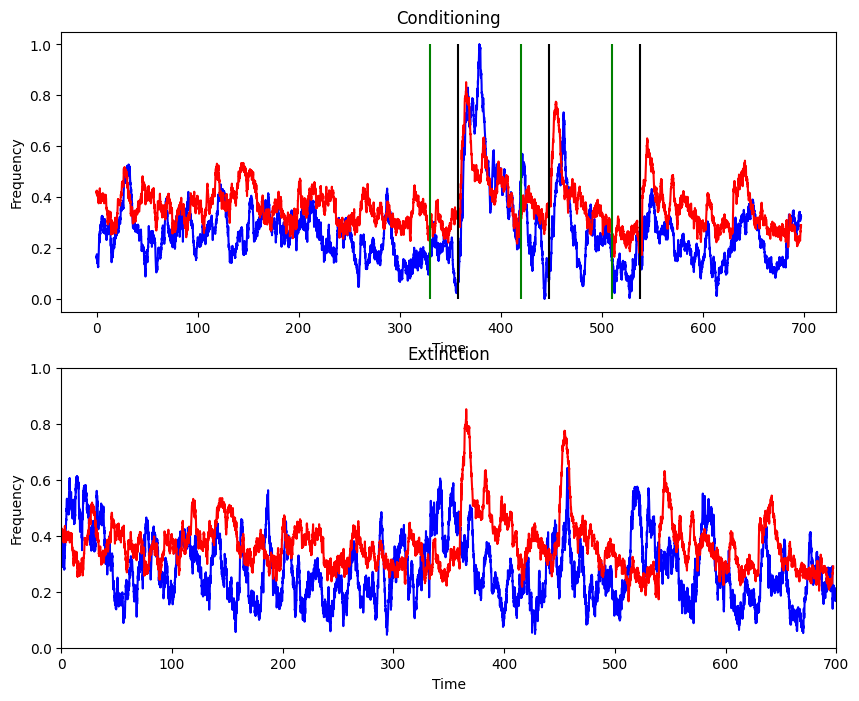

In [7]:
# 9 subplots

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

axes[0].plot(time_conditioning, conditioning_traces[:, 0], color='blue')
axes[0].plot(time_conditioning, conditioning_traces[:, 1], color='red')
axes[0].vlines(shock_index, ymin=0, ymax=1, color='black')
axes[0].vlines(tone_index, ymin=0, ymax=1, color= 'green')
axes[0].set_title('Conditioning')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Frequency')

axes[1].plot(time_extinction, extinction_traces[:, 0], color='blue')
axes[1].plot(time_conditioning, conditioning_traces[:, 1], color='red')
axes[1].set_title('Extinction')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Frequency')
axes[1].set_ylim(0, 1)
axes[1].set_xlim(0, 700)

Red(ROI 2) seems to be stronger than blue(ROI 1) in bnoth conditioning and extinction

stronger activity after stimulus in conditioning over extinction, blue seems to be quicker to forget learning

In [51]:
#12 predictors

shock_array = np.zeros(10458)
for i in range(10458):
  if i >= (shock_index[0]-15)*15 and i <= (shock_index[0]+30)*15:
    shock_array[i] = 1
  elif i>= (shock_index[1]-15)*15 and i <= (shock_index[1]+30)*15:
    shock_array[i] = 1
  elif i>= (shock_index[2]-15)*15 and i <= (shock_index[2]+30)*15:
    shock_array[i] = 1
  else:
    shock_array[i] = 0

tone_array = np.zeros(10458)
for i in range(10458):
  if i >= (tone_index[0]-15)*15 and i <= (tone_index[0]+30)*15:
    tone_array[i] = 1
  elif i>= (tone_index[1]-15)*15 and i <= (tone_index[1]+30)*15:
    tone_array[i] = 1
  elif i>= (tone_index[2]-15)*15 and i <= (tone_index[2]+30)*15:
    tone_array[i] = 1
  else:
    tone_array[i] = 0

import pandas as pd
from pandas import DataFrame as df
import statsmodels.api as sm
from statsmodels.genmod.families import Poisson
from statsmodels.genmod.families.links import identity, log
from scipy.stats import chi2
from statsmodels.distributions.empirical_distribution import ECDF

predictors_conditioning = df(data={'intercept': np.ones_like(tone_array),'tone onset': tone_array,'shock onset': shock_array})
tone_array_extinction = np.zeros(14210)
for i in range(14210):
  for t in tone_index:
    if 1 >= (t-15)*15 and i <= (t+30)*15:
      tone_array_extinction[i] = 1

predictors_extinction = df(data={'Intercept': np.ones_like(tone_array_extinction),'tone onset': tone_array_extinction})

Text(0, 0.5, 'proprotion of ROIs')

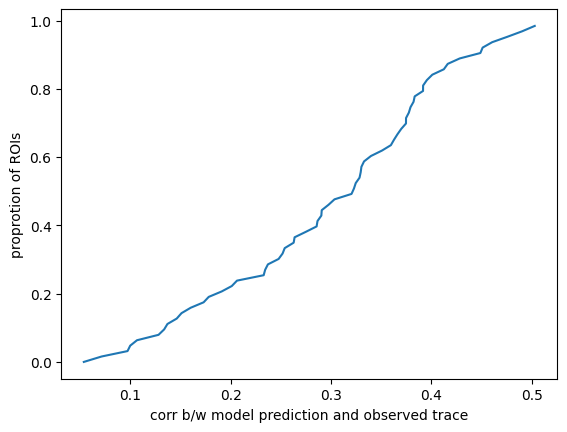

In [65]:
# 13 run model for conditioning

r_index_conditioning = np.zeros(63)

for i in range(63):
    trace = conditioning_traces[:, i]
    model = sm.GLM(trace, predictors_conditioning)
    results = model.fit()
    predicted = results.predict(predictors_conditioning)
    r, _ = pearsonr(trace, predicted)
    r_index_conditioning[i] = r

plt.plot(np.sort(r_index_conditioning), np.linspace(0, 1, len(r_index_conditioning), endpoint=False))
plt.xlabel('corr b/w model prediction and observed trace')
plt.ylabel('proprotion of ROIs')

Text(0, 0.5, 'proprotion of ROIs')

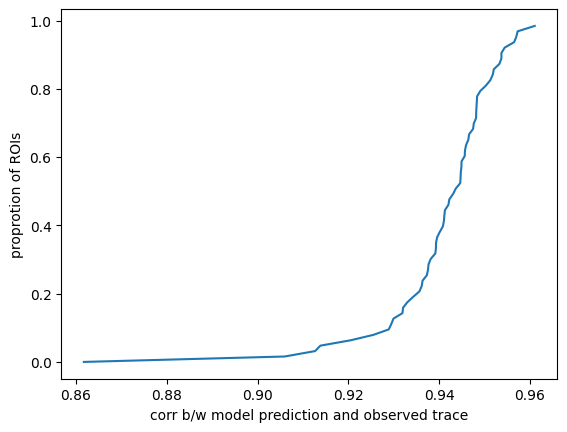

In [66]:
#14 run model for extinction

r_index_extinction = np.zeros(extinction_traces.shape[1])

for i in range(63):
    trace = extinction_traces[:, i]
    model = sm.GLM(trace, extinction_traces, family=Poisson())
    model_results = model.fit()
    predicted = model_results.predict()
    r = pearsonr(trace, predicted)
    r_index_extinction[i] = r.statistic

plt.plot(np.sort(r_index_extinction), np.linspace(0, 1, len(r_index_extinction), endpoint=False))
plt.xlabel('corr b/w model prediction and observed trace')
plt.ylabel('proprotion of ROIs')

In [59]:
#15 correlate variables

r, p = pearsonr(r_index_conditioning, r_index_extinction)
print(r, p)

0.20425557926684348 0.10833049847059446


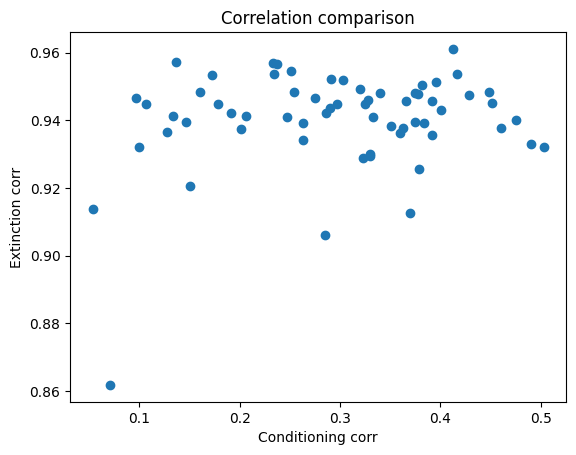

In [57]:
# scatter

plt.scatter(r_index_conditioning, r_index_extinction)
plt.xlabel("Conditioning corr")
plt.ylabel("Extinction corr")
plt.title("Correlation comparison")
plt.show()

My data does not show a clear correlation.